<a href="https://colab.research.google.com/github/sivadharshangiri222-web/predictive-analytics-sales-forecasting/blob/main/Predictive_Analytics_Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

data = {
    "Month": [
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
    ],

    "Advertising": [
        10000, 12000, 14000, 13000, 15000, 17000,
        18000, 19000, 21000, 22000, 24000, 26000
    ],

    "Customers": [
        400, 430, 450, 440, 480, 500,
        520, 540, 570, 590, 620, 650
    ],

    "Sales": [
        50000, 54000, 57000, 55000, 61000, 65000,
        68000, 71000, 75000, 79000, 83000, 88000
    ]
}

df = pd.DataFrame(data)

df

,Month,Advertising,Customers,Sales
0,Jan,10000,400,50000
1,Feb,12000,430,54000
2,Mar,14000,450,57000
3,Apr,13000,440,55000
4,May,15000,480,61000
5,Jun,17000,500,65000
6,Jul,18000,520,68000
7,Aug,19000,540,71000
8,Sep,21000,570,75000
9,Oct,22000,590,79000


In [2]:
df.head()

,Month,Advertising,Customers,Sales
0,Jan,10000,400,50000
1,Feb,12000,430,54000
2,Mar,14000,450,57000
3,Apr,13000,440,55000
4,May,15000,480,61000


In [3]:
df.shape

(12, 4)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        12 non-null     object
 1   Advertising  12 non-null     int64 
 2   Customers    12 non-null     int64 
 3   Sales        12 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 516.0+ bytes


In [5]:
df.describe()

,Advertising,Customers,Sales
count,12.000000,12.000000,12.000000
mean,17583.333333,515.833333,67166.666667
std,4999.242367,79.938423,12298.065874
min,10000.000000,400.000000,50000.000000
25%,13750.000000,447.500000,56500.000000
50%,17500.000000,510.000000,66500.000000
75%,21250.000000,575.000000,76000.000000
max,26000.000000,650.000000,88000.000000


In [6]:
df.isnull().sum()

,0
Month,0
Advertising,0
Customers,0
Sales,0


In [7]:
df.duplicated().sum()

np.int64(0)

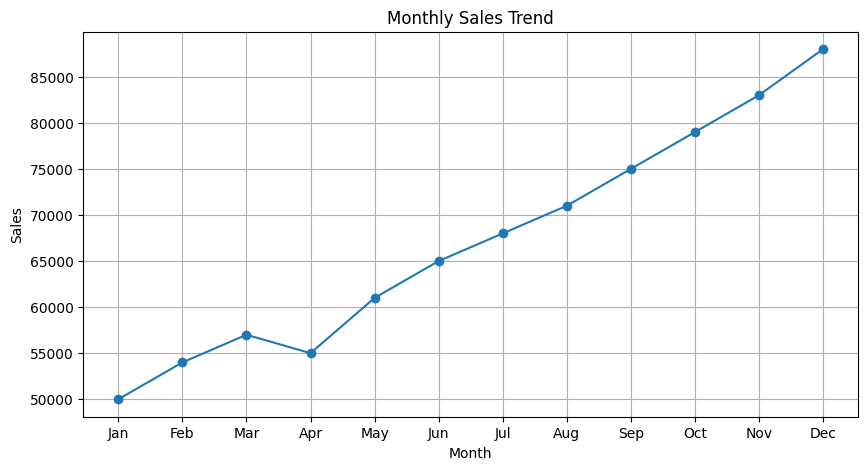

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df["Month"], df["Sales"], marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

In [9]:
X = df[["Advertising", "Customers"]]

y = df["Sales"]

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)

print("Predicted Sales:")
print(y_pred)

Predicted Sales:
[83172.8450201  78448.8610987  48872.71103171]


In [14]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison

,Actual Sales,Predicted Sales
0,83000,83172.845020
1,79000,78448.861099
2,50000,48872.711032


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 617.0909632276307
Mean Squared Error (MSE): 534803.3025068935
Root Mean Squared Error (RMSE): 731.3024699171291
R² Score: 0.9975266034313659


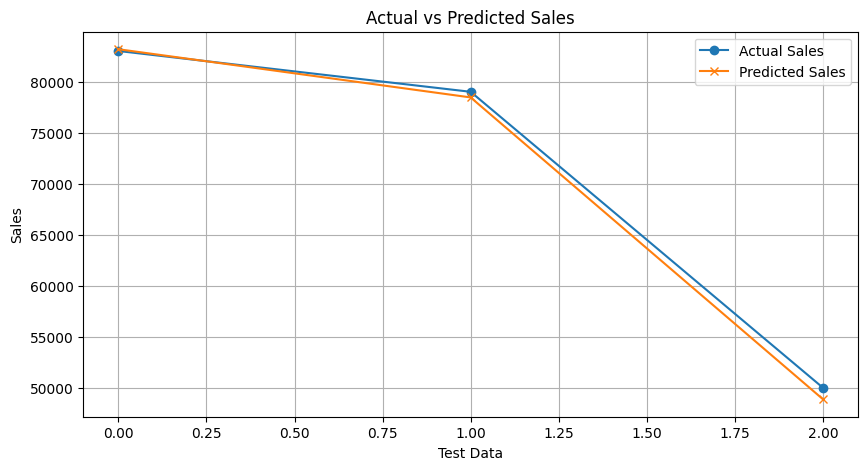

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    y_pred,
    marker="x",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Data")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

In [17]:
# Future input data

future_data = pd.DataFrame({
    "Advertising": [28000],
    "Customers": [700]
})

# Predict future sales
future_prediction = model.predict(future_data)

print("Predicted Future Sales:", future_prediction[0])

Predicted Future Sales: 95085.30594015187


In [18]:
predicted_sales = future_prediction[0]

print(f"Predicted Future Sales: ₹{predicted_sales:,.2f}")

Predicted Future Sales: ₹95,085.31


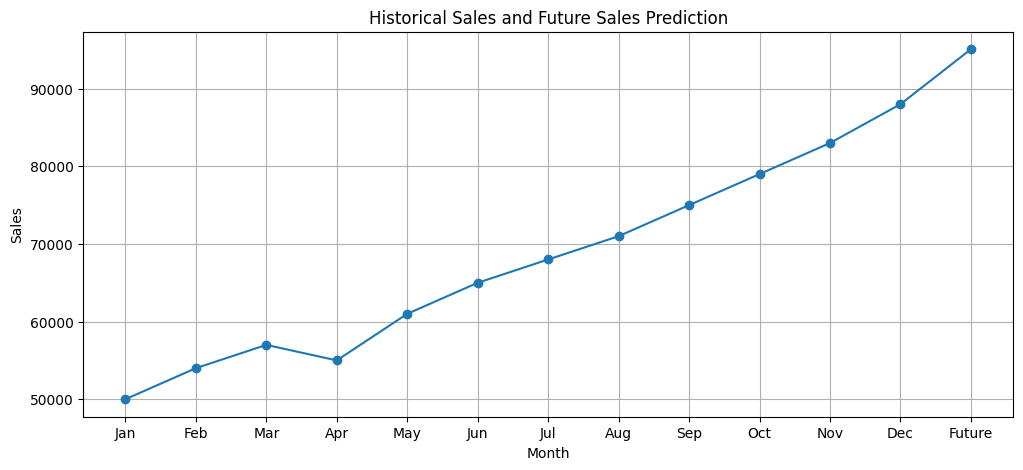

In [19]:
# Historical months
months = df["Month"].tolist()

# Historical sales
sales = df["Sales"].tolist()

# Add future prediction
months_with_future = months + ["Future"]
sales_with_future = sales + [predicted_sales]

# Plot
plt.figure(figsize=(12, 5))

plt.plot(
    months_with_future,
    sales_with_future,
    marker="o"
)

plt.title("Historical Sales and Future Sales Prediction")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

In [20]:
future_result = pd.DataFrame({
    "Advertising": [28000],
    "Customers": [700],
    "Predicted Sales": [predicted_sales]
})

future_result

,Advertising,Customers,Predicted Sales
0,28000,700,95085.30594


## Conclusion

In this project, historical sales data was analyzed and used to build a predictive analytics model using Linear Regression. The dataset was cleaned and preprocessed before training the model. The model was evaluated using MAE, MSE, RMSE, and R² Score. Finally, the trained model was used to predict future sales based on advertising expenditure and the expected number of customers.

This project demonstrates how machine learning can be used to identify patterns in historical data and support future trend forecasting.